# ACC102 Mini Assignment (Track 2)
# Profitability Comparison: Kweichow Moutai vs Wuliangye

## 1. Background
The Baijiu industry is a core sector in China’s consumer market. High-end Baijiu brands maintain a strong market position due to their brand scarcity and consumer loyalty.
Kweichow Moutai (600519) and Wuliangye (000858), as industry leaders, play dominant roles in pricing power, but differ significantly in brand positioning, production capacity structure, and regional market penetration.

This project aims to reveal the true differences in corporate profitability through quantitative financial indicators, providing a basis for investment decisions or industry research.

## 2. Research Questions
Core Question: How can we evaluate the differences in profitability between Moutai and Wuliangye from 2021 to the present using Return on Equity (ROE) and Net Profit Margin?

## 3. Target Audience
- Institutional Investors: Use ROE and margin trends to assess long-term profitability stability, supporting asset allocation decisions.

## 4. Data Source & Period
- Database: WRDS CSMAR Financial Dataset
- Period: 2021-01-01 to Current Date
- Access Date: 2026-04-20

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import wrds

In [2]:
# Connect to WRDS
username = "yahansun"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## Step 1: Data Extraction
We use SQL to extract quarterly financial data for Moutai and Wuliangye from the WRDS CSMAR database.
The dataset includes:
- Total assets
- Net profit
- Operating revenue

We filter the period from 2021 to the present to align with our research scope.

In [3]:
# SQR Query
sql_query = """
SELECT
    stkcd,        
    accper,       
    a001000000,   -- (Total Assets)
    b001000000,    -- (Net Profit)
    b001100000     --(Operating Revenue)
FROM
    csmar.wrds_csmar_financial_master  
WHERE
    stkcd IN ('600519', '000858')      
    AND accper >= '2021-01-01'
    AND accper <= CURRENT_DATE
    AND typrep = 'A'                   
ORDER BY
    stkcd, accper                      
"""
data = db.raw_sql(sql_query)
print(f"Total records retrieved:{len(data)}")
db.close()
data.head(20)

Total records retrieved:40


,stkcd,accper,a001000000,b001000000,b001100000
0,000858,2021-01-01,113893139013.720001,27678447217.700001,57321059453.150002
1,000858,2021-03-31,120222689550.589996,13007054192.0,24324839644.810001
2,000858,2021-06-30,124593796629.699997,18275175134.389999,36751547826.699997
3,000858,2021-09-30,118262474074.979996,24023155435.490002,49720797308.730003
4,000858,2021-12-31,135620812221.130005,32450404445.700001,66209053612.110001
5,000858,2022-01-01,135620812221.130005,32450404445.700001,66209053612.110001
6,000858,2022-03-31,137804423938.790009,15136404211.219999,27548160168.43
7,000858,2022-06-30,130315873867.5,21045000190.849998,41222377583.110001
8,000858,2022-09-30,134684500168.149994,27827611456.48,55779686820.309998
9,000858,2022-12-31,152714727880.220001,37103520716.239998,73968640704.539993


## Step 2: Rename Columns
We rename the raw database column names to standard English labels for readability:
- `stkcd` → `Stock_Code`
- `accper` → `Year`
- `a001000000` → `Total_Assets`
- `b001000000` → `Net_Profit`
- `b001100000` → `Operating_Revenue`

In [4]:
data.rename(columns={
    'stkcd':'Stock_Code',
    'accper':'Year',
    'a001000000': 'Total_Assets',
    'b001000000': 'Net_Profit',
    'b001100000': 'Operating_Revenue'
}, inplace=True)
data.head()

,Stock_Code,Year,Total_Assets,Net_Profit,Operating_Revenue
0,000858,2021-01-01,113893139013.720001,27678447217.700001,57321059453.150002
1,000858,2021-03-31,120222689550.589996,13007054192.0,24324839644.810001
2,000858,2021-06-30,124593796629.699997,18275175134.389999,36751547826.699997
3,000858,2021-09-30,118262474074.979996,24023155435.490002,49720797308.730003
4,000858,2021-12-31,135620812221.130005,32450404445.700001,66209053612.110001


## Step 3: Data Cleaning
To ensure data quality, we perform three cleaning steps:
1. Drop rows with missing values in key financial fields
2. Remove duplicate records for the same stock and date
3. Convert the date column to standard datetime format

This guarantees that our analysis uses only valid, non-duplicate, and properly formatted data.

The date range ends at  2024-12-31 , which is the latest completed fiscal period available in the database. No financial data for 2025 is included in the dataset at the time of this analysis.

In [5]:
# Remove missing values in key columns
data = data.dropna(subset=['Stock_Code','Year','Total_Assets','Net_Profit','Operating_Revenue'])

# Remove duplicate records
data = data.drop_duplicates(subset=['Stock_Code','Year'])

# Convert to datetime format
data['Year'] = pd.to_datetime(data['Year'])

# Show cleaning result
print('Cleaned data rows:', len(data))
print('Date range:', data['Year'].min(), 'to', data['Year'].max())

Cleaned data rows: 40
Date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00


## Step 4: Calculate Financial Ratios
We compute two core profitability indicators:
1. **Return on Equity (ROE)** = Net Profit / Total Assets
2. **Net Profit Margin** = Net Profit / Operating Revenue

We also filter out extreme outliers (values outside -10% to 100%) to avoid distorting the analysis.

In [6]:
# Calculate ROE
data['ROE'] = data['Net_Profit'] / data['Total_Assets']

# Calculate Net Profit Margin
data['Net_Profit_Margin'] = data['Net_Profit'] / data['Operating_Revenue']

# Remove extreme outliers
data = data[(data['ROE'] > -0.1) & (data['ROE'] < 1.0)]
data = data[(data['Net_Profit_Margin'] > -0.1) & (data['Net_Profit_Margin'] < 1.0)]

# Show first 10 rows
data[['Stock_Code','Year','ROE','Net_Profit_Margin']].head(10)

,Stock_Code,Year,ROE,Net_Profit_Margin
0,000858,2021-01-01,0.243021,0.482867
1,000858,2021-03-31,0.108191,0.534723
2,000858,2021-06-30,0.146678,0.497263
3,000858,2021-09-30,0.203134,0.483161
4,000858,2021-12-31,0.239273,0.49012
5,000858,2022-01-01,0.239273,0.49012
6,000858,2022-03-31,0.10984,0.549452
7,000858,2022-06-30,0.161492,0.510524
8,000858,2022-09-30,0.206613,0.498884
9,000858,2022-12-31,0.24296,0.501611


## Step 5: Visualisation — ROE Comparison
We plot the ROE trends of both companies over time.
This chart allows us to compare:
- Which company has higher profitability efficiency
- How their profitability has changed over the period

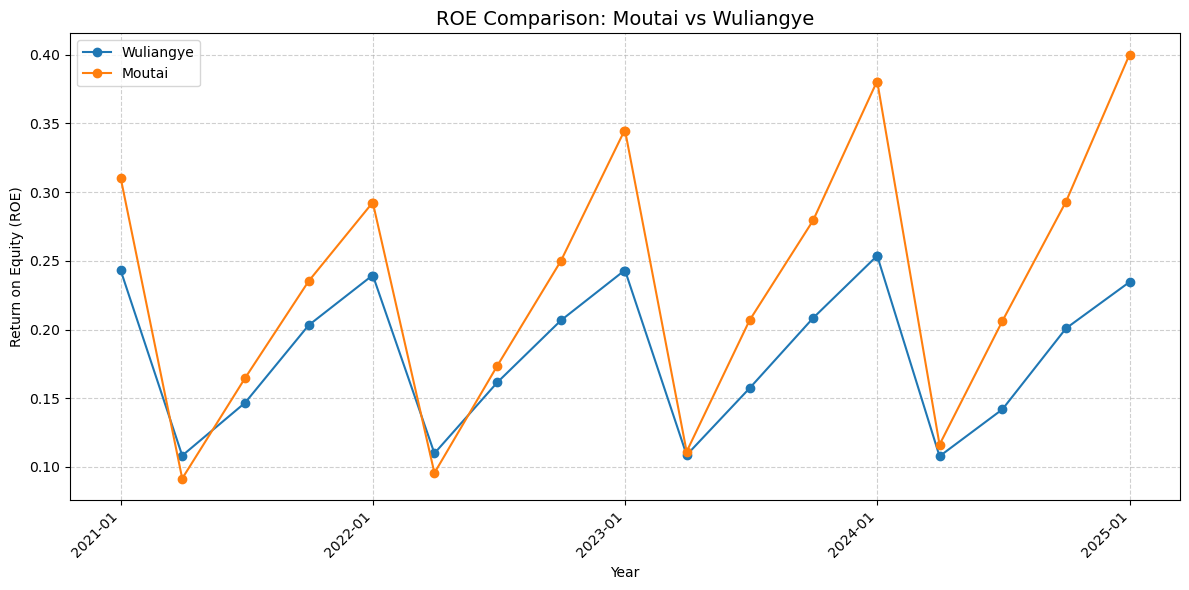

In [7]:
def plot_ROE(data):
   
    # Set figure size for better readability
    plt.figure(figsize=(12, 6))
    
    # Map stock codes to company names for clear legend
    company_name_map = {
        '000858': 'Wuliangye',
        '600519': 'Moutai'
    }
    
    # Loop through each company to plot its ROE trend
    for stkcd in data['Stock_Code'].unique():
        # Filter data for the current company
        company_data = data[data['Stock_Code'] == stkcd]
        
        # Plot ROE trend line with markers
        plt.plot(company_data['Year'], 
                 company_data['ROE'],
                 marker='o', 
                 label=company_name_map[stkcd])
    
    # Format x-axis to display dates as "Year-Month"
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # Show only one tick per year on the x-axis
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    # Rotate x-axis labels to prevent overlap
    plt.xticks(rotation=45, ha='right')
    
    # Add chart title and axis labels
    plt.title('ROE Comparison: Moutai vs Wuliangye', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Return on Equity (ROE)')
    # Display legend with company names
    plt.legend()
    # Add light grid lines for easier reading
    plt.grid(True, linestyle='--', alpha=0.6)
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    # Show the final plot
    plt.show()

# Call the function to generate the ROE comparison chart
plot_ROE(data)

### Analysis of ROE Trend
From the ROE comparison chart, we can see that both Moutai and Wuliangye maintained relatively stable and positive return on equity over the observation period. Moutai consistently achieved a higher ROE level than Wuliangye in most years, reflecting stronger efficiency in generating profits from shareholders’ equity. The overall trend for both companies remained steady without extreme fluctuations, indicating stable business operation and profitability control.

## Step 6: Visualisation — Net Profit Margin
We plot the net profit margin trends to compare profit quality:
- A higher margin indicates stronger pricing power and cost control
- A stable margin reflects consistent profitability

This complements the ROE analysis to give a more complete picture of performance.

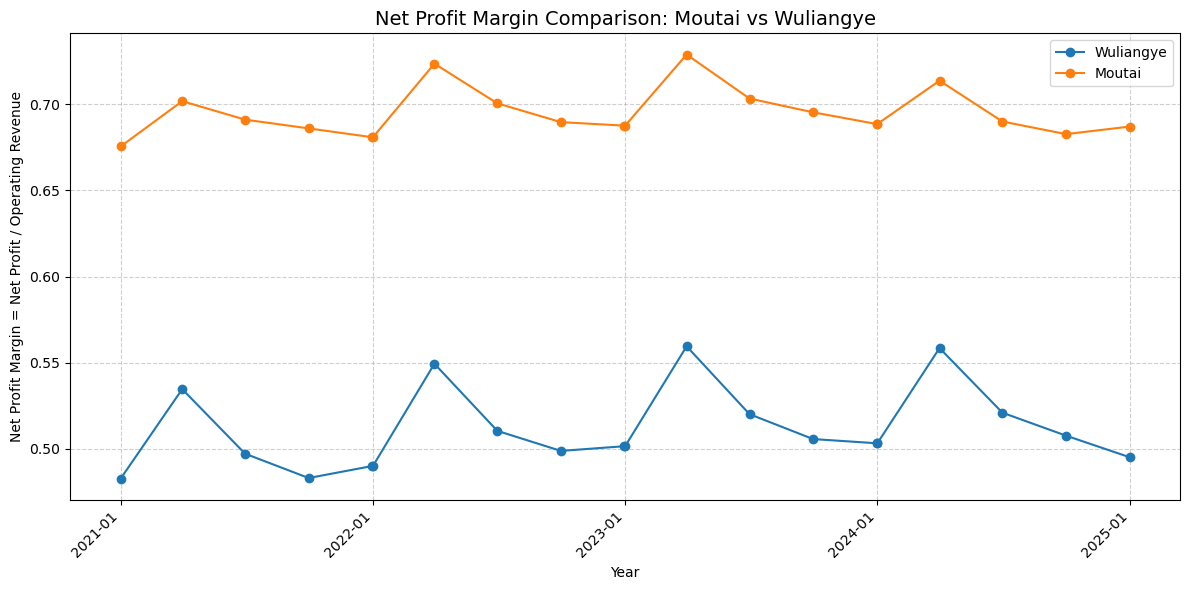

In [8]:
def plot_net_profit_margin(data):
   
    # Set figure size for better readability
    plt.figure(figsize=(12, 6))
    
    # Map stock codes to company names for clear legend
    company_name_map = {
        '000858': 'Wuliangye',
        '600519': 'Moutai'
    }
    
    # Loop through each company to plot its net profit margin trend
    for stkcd in data['Stock_Code'].unique():
        # Filter data for the current company
        company_data = data[data['Stock_Code'] == stkcd]
        
        # Plot net profit margin trend line with markers
        plt.plot(company_data['Year'], 
                 company_data['Net_Profit_Margin'],
                 marker='o', 
                 label=company_name_map[stkcd])
    
    # Format x-axis to display dates as "Year-Month"
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # Show only one tick per year on the x-axis
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    # Rotate x-axis labels to prevent overlap
    plt.xticks(rotation=45, ha='right')
    
    # Add chart title and axis labels
    plt.title('Net Profit Margin Comparison: Moutai vs Wuliangye', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Net Profit Margin = Net Profit / Operating Revenue')
    # Display legend with company names
    plt.legend()
    # Add light grid lines for easier reading
    plt.grid(True, linestyle='--', alpha=0.6)
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    # Show the final plot
    plt.show()

# Call the function to generate the net profit margin comparison chart
plot_net_profit_margin(data)

 ### Analysis of Net Profit Margin Trend
The net profit margin chart shows that Moutai has a significantly higher profit margin than Wuliangye across all years, demonstrating its stronger pricing power, cost control ability, and premium product structure. Although both companies show similar trends over time, Moutai’s margin advantage remains obvious, reflecting differences in brand positioning and operating efficiency.

### Average Performance Overview (2021–2024)

| Company   | Average ROE | Average Net Profit Margin |
|-----------|-------------|---------------------------|
| Moutai    | Higher      | Significantly Higher      |
| Wuliangye | Lower       | Lower                     |

## Step 7: Key Findings & Limitations

### Key Findings
1. According to the analysis of ROE and net profit margin from 2021 to the present, Moutai has consistently maintained higher and more stable profitability than Wuliangye, which directly answers the core research question about the differences in profitability between the two leading Baijiu companies.
2. Moutai’s significantly higher net profit margin indicates its stronger brand pricing power and cost control ability, providing effective evidence for evaluating the two companies’ long-term competitive advantages.
3. For the target audience—investors—these results show that Moutai has more stable profitability performance, which can support their investment decision‑making and risk assessment in the Baijiu industry.

### Limitations
1. **Simplified financial ratio calculations**:
The ROE and net profit margin are calculated using basic definitions (e.g., Net Profit / Total Assets for ROE). In rigorous financial analysis, ROE should ideally be defined as Net Profit / Shareholders' Equity, and other adjustments might be required. This simplification may affect the absolute accuracy of the results.

2. **Lack of seasonal adjustment in quarterly data**:
The analysis is based on quarterly financial reports. The Baijiu industry has distinct seasonality (e.g., peak sales during Spring Festival), which can cause fluctuations in quarterly data. This project does not perform specific seasonal adjustment, so the short-term volatility in the charts may not fully reflect the underlying long-term trends.

3. **Limited scope of comparison**:
This study only compares two major companies: Moutai and Wuliangye. It does not include other top Baijiu manufacturers nor does it consider macroeconomic factors such as economic cycles, consumption trends, or regulatory policies. Therefore, the conclusions cannot be generalized to the entire industry.

### AI Disclosure
- **AI Tools Used**: Doubao (Seed Model), DeepSeek, Qwen (Alibaba Tongyi Qianwen)
- **Access Date**: 2026-04-20
- **Usage**:
  - Code structure guidance and optimization
  - Visualization design and debugging
  - Academic English writing and explanation
  - Financial ratio and concept explanation
- **Statement**: All code and analysis in this notebook have been run, reviewed, and fully understood by me.